<a href="https://www.kaggle.com/code/youssefhazem75/f1-prediction?scriptVersionId=356769996" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
circuits_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/circuits.csv', index_col=0, na_values='\\N')
circuits_df.info()
circuits_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 77 entries, 1 to 79
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitRef  77 non-null     object 
 1   name        77 non-null     object 
 2   location    77 non-null     object 
 3   country     77 non-null     object 
 4   lat         77 non-null     float64
 5   lng         77 non-null     float64
 6   alt         77 non-null     int64  
 7   url         77 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 5.4+ KB


,circuitRef,name,location,country,lat,lng,alt,url
circuitId,,,,,,,,
1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


In [3]:
constructor_results_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_results.csv', index_col=0, na_values='\\N')
constructor_results_df.info()
constructor_results_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 12625 entries, 1 to 17129
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raceId         12625 non-null  int64  
 1   constructorId  12625 non-null  int64  
 2   points         12625 non-null  float64
 3   status         17 non-null     object 
dtypes: float64(1), int64(2), object(1)
memory usage: 493.2+ KB


,raceId,constructorId,points,status
constructorResultsId,,,,
1,18,1,14.0,NaN
2,18,2,8.0,NaN
3,18,3,9.0,NaN
4,18,4,5.0,NaN
5,18,5,2.0,NaN


In [4]:
constructor_standings_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructor_standings.csv', index_col=0, na_values='\\N')
constructor_standings_df.info()
constructor_standings_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 13391 entries, 1 to 28982
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   raceId         13391 non-null  int64  
 1   constructorId  13391 non-null  int64  
 2   points         13391 non-null  float64
 3   position       13391 non-null  int64  
 4   positionText   13391 non-null  object 
 5   wins           13391 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 732.3+ KB


,raceId,constructorId,points,position,positionText,wins
constructorStandingsId,,,,,,
1,18,1,14.0,1,1,1
2,18,2,8.0,3,3,0
3,18,3,9.0,2,2,0
4,18,4,5.0,4,4,0
5,18,5,2.0,5,5,0


In [5]:
constructors_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/constructors.csv', index_col=0, na_values='\\N')
constructors_df.info()
constructors_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 1 to 215
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorRef  212 non-null    object
 1   name            212 non-null    object
 2   nationality     212 non-null    object
 3   url             212 non-null    object
dtypes: object(4)
memory usage: 8.3+ KB


,constructorRef,name,nationality,url
constructorId,,,,
1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


In [6]:
driver_standings_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/driver_standings.csv', index_col=0, na_values='\\N')
driver_standings_df.info()
driver_standings_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 34863 entries, 1 to 73270
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   raceId        34863 non-null  int64  
 1   driverId      34863 non-null  int64  
 2   points        34863 non-null  float64
 3   position      34863 non-null  int64  
 4   positionText  34863 non-null  object 
 5   wins          34863 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 1.9+ MB


,raceId,driverId,points,position,positionText,wins
driverStandingsId,,,,,,
1,18,1,10.0,1,1,1
2,18,2,8.0,2,2,0
3,18,3,6.0,3,3,0
4,18,4,5.0,4,4,0
5,18,5,4.0,5,5,0


In [7]:
drivers_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/drivers.csv', index_col=0, na_values='\\N')
drivers_df.info()
drivers_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 861 entries, 1 to 862
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   driverRef    861 non-null    object 
 1   number       59 non-null     float64
 2   code         104 non-null    object 
 3   forename     861 non-null    object 
 4   surname      861 non-null    object 
 5   dob          861 non-null    object 
 6   nationality  861 non-null    object 
 7   url          861 non-null    object 
dtypes: float64(1), object(7)
memory usage: 60.5+ KB


,driverRef,number,code,forename,surname,dob,nationality,url
driverId,,,,,,,,
1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [8]:
lap_times_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/lap_times.csv', index_col=0, na_values='\\N')
lap_times_df.info()
lap_times_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 589081 entries, 841 to 1144
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   driverId      589081 non-null  int64 
 1   lap           589081 non-null  int64 
 2   position      589081 non-null  int64 
 3   time          589081 non-null  object
 4   milliseconds  589081 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 27.0+ MB


,driverId,lap,position,time,milliseconds
raceId,,,,,
841,20,1,1,1:38.109,98109
841,20,2,1,1:33.006,93006
841,20,3,1,1:32.713,92713
841,20,4,1,1:32.803,92803
841,20,5,1,1:32.342,92342


In [9]:
pit_stops_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/pit_stops.csv', index_col=0, na_values='\\N')
pit_stops_df.info()
pit_stops_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 11371 entries, 841 to 1144
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   driverId      11371 non-null  int64 
 1   stop          11371 non-null  int64 
 2   lap           11371 non-null  int64 
 3   time          11371 non-null  object
 4   duration      11371 non-null  object
 5   milliseconds  11371 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 621.9+ KB


,driverId,stop,lap,time,duration,milliseconds
raceId,,,,,,
841,153,1,1,17:05:23,26.898,26898
841,30,1,1,17:05:52,25.021,25021
841,17,1,11,17:20:48,23.426,23426
841,4,1,12,17:22:34,23.251,23251
841,13,1,13,17:24:10,23.842,23842


In [10]:
qualifying_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/qualifying.csv', index_col=0, na_values='\\N')
qualifying_df.info()
qualifying_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 10494 entries, 1 to 10551
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   raceId         10494 non-null  int64 
 1   driverId       10494 non-null  int64 
 2   constructorId  10494 non-null  int64 
 3   number         10494 non-null  int64 
 4   position       10494 non-null  int64 
 5   q1             10338 non-null  object
 6   q2             5847 non-null   object
 7   q3             3629 non-null   object
dtypes: int64(5), object(3)
memory usage: 737.9+ KB


,raceId,driverId,constructorId,number,position,q1,q2,q3
qualifyId,,,,,,,,
1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [11]:
races_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/races.csv', index_col=0, na_values='\\N')
races_df.info()
races_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1125 entries, 1 to 1144
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   year         1125 non-null   int64 
 1   round        1125 non-null   int64 
 2   circuitId    1125 non-null   int64 
 3   name         1125 non-null   object
 4   date         1125 non-null   object
 5   time         394 non-null    object
 6   url          1125 non-null   object
 7   fp1_date     90 non-null     object
 8   fp1_time     68 non-null     object
 9   fp2_date     90 non-null     object
 10  fp2_time     68 non-null     object
 11  fp3_date     72 non-null     object
 12  fp3_time     53 non-null     object
 13  quali_date   90 non-null     object
 14  quali_time   68 non-null     object
 15  sprint_date  18 non-null     object
 16  sprint_time  15 non-null     object
dtypes: int64(3), object(14)
memory usage: 158.2+ KB


,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
raceId,,,,,,,,,,,,,,,,,
1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
results_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/results.csv', index_col=0, na_values='\\N')
results_df.info()
results_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 26759 entries, 1 to 26764
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   raceId           26759 non-null  int64  
 1   driverId         26759 non-null  int64  
 2   constructorId    26759 non-null  int64  
 3   number           26753 non-null  float64
 4   grid             26759 non-null  int64  
 5   position         15806 non-null  float64
 6   positionText     26759 non-null  object 
 7   positionOrder    26759 non-null  int64  
 8   points           26759 non-null  float64
 9   laps             26759 non-null  int64  
 10  time             7680 non-null   object 
 11  milliseconds     7680 non-null   float64
 12  fastestLap       8252 non-null   float64
 13  rank             8510 non-null   float64
 14  fastestLapTime   8252 non-null   object 
 15  fastestLapSpeed  8252 non-null   float64
 16  statusId         26759 non-null  int64  
dtypes: float64(7), in

,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
resultId,,,,,,,,,,,,,,,,,
1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
4,18,4,4,5.0,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
5,18,5,1,23.0,3,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


In [13]:
# Check for duplicate (raceId, driverId) combinations
dup_check = results_df.groupby(['raceId', 'driverId']).size()
duplicates = dup_check[dup_check > 1]

print(f"Number of duplicate (raceId, driverId) pairs: {len(duplicates)}")
print(f"\nSample duplicates:")
print(duplicates.head(10))

# Look at what one of these actually looks like
first_dup_race = duplicates.index[0][0]
first_dup_driver = duplicates.index[0][1]
print(f"\nBoth rows for raceId={first_dup_race}, driverId={first_dup_driver}:")
print(results_df[
    (results_df['raceId'] == first_dup_race) & 
    (results_df['driverId'] == first_dup_driver)
][['raceId','driverId','grid','positionOrder','positionText','points']])

Number of duplicate (raceId, driverId) pairs: 85

Sample duplicates:
raceId  driverId
540     229         2
717     373         2
733     465         2
742     475         2
745     418         2
746     475         2
766     541         2
770     479         2
774     566         2
776     581         2
dtype: int64

Both rows for raceId=540, driverId=229:
          raceId  driverId  grid  positionOrder positionText  points
resultId                                                            
13189        540       229     0             26            F     0.0
13192        540       229     0             29            F     0.0


In [14]:
seasons_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/seasons.csv', index_col=0, na_values='\\N')
seasons_df.info()
seasons_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 2009 to 2024
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     75 non-null     object
dtypes: object(1)
memory usage: 1.2+ KB


,url
year,
2009,http://en.wikipedia.org/wiki/2009_Formula_One_...
2008,http://en.wikipedia.org/wiki/2008_Formula_One_...
2007,http://en.wikipedia.org/wiki/2007_Formula_One_...
2006,http://en.wikipedia.org/wiki/2006_Formula_One_...
2005,http://en.wikipedia.org/wiki/2005_Formula_One_...


In [15]:
sprint_results_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/sprint_results.csv', index_col=0, na_values='\\N')
sprint_results_df.info()
sprint_results_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 360 entries, 1 to 360
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   raceId          360 non-null    int64  
 1   driverId        360 non-null    int64  
 2   constructorId   360 non-null    int64  
 3   number          360 non-null    int64  
 4   grid            360 non-null    int64  
 5   position        345 non-null    float64
 6   positionText    360 non-null    object 
 7   positionOrder   360 non-null    int64  
 8   points          360 non-null    int64  
 9   laps            360 non-null    int64  
 10  time            340 non-null    object 
 11  milliseconds    340 non-null    float64
 12  fastestLap      351 non-null    float64
 13  fastestLapTime  351 non-null    object 
 14  statusId        360 non-null    int64  
dtypes: float64(3), int64(9), object(3)
memory usage: 45.0+ KB


,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,fastestLapTime,statusId
resultId,,,,,,,,,,,,,,,
1,1061,830,9,33,2,1.0,1,1,3,17,25:38.426,1538426.0,14.0,1:30.013,1
2,1061,1,131,44,1,2.0,2,2,2,17,+1.430,1539856.0,17.0,1:29.937,1
3,1061,822,131,77,3,3.0,3,3,1,17,+7.502,1545928.0,17.0,1:29.958,1
4,1061,844,6,16,4,4.0,4,4,0,17,+11.278,1549704.0,16.0,1:30.163,1
5,1061,846,1,4,6,5.0,5,5,0,17,+24.111,1562537.0,16.0,1:30.566,1


In [16]:
status_df = pd.read_csv('/kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020/status.csv', index_col=0, na_values='\\N')
status_df.info()
status_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 139 entries, 1 to 141
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   status  139 non-null    object
dtypes: object(1)
memory usage: 2.2+ KB


,status
statusId,
1,Finished
2,Disqualified
3,Accident
4,Collision
5,Engine


# 🔍 Exploratory Data Analysis

Before we can build a model, we need to deeply understand the data we are working with. This section answers four questions:

1. **What does our target variable look like?** — Is `positionOrder` the right column? How imbalanced is our positive class (podium)?
2. **Which rows should we keep?** — Some entries are drivers who never started (DNQs). Should they be included?
3. **What is our strongest predictive signal?** — Grid position turns out to be extremely predictive of podium finishes.
4. **What coverage do we have for qualifying data?** — We need to know from which year we can reliably use qualifying lap times as features.

We work entirely from `results_df` merged with `races_df` (for the year). No cleaning has been applied yet — we are observing the raw data.

## Inspecting `results_df`

`results_df` is the central table for our project. Every row represents one driver in one race. We need to check:
- **How many rows and columns** does it have?
- **Which columns have null values?** — This tells us what data is missing and whether it is a problem.
- **What values does `positionText` take?** — This column encodes the race outcome (finished, retired, did not qualify, etc.) and is key to defining our target variable.

In [17]:
print("Shape:", results_df.shape)
print("\nNull counts:")
print(results_df.isnull().sum())
print("\nSample positionText values:")
print(results_df['positionText'].value_counts().head(15))

Shape: (26759, 17)

Null counts:
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64

Sample positionText values:
positionText
R     8897
F     1368
3     1135
4     1135
2     1133
5     1131
1     1128
6     1124
7     1104
8     1076
9     1038
10     978
11     902
12     800
13     713
Name: count, dtype: int64


**What we found:**
- The table has **26,759 rows** (one per driver per race entry) and **17 columns**.
- **`position`** has 10,953 nulls — this column is blank for drivers who retired or did not finish. We must use **`positionOrder`** instead, which is always filled and assigns a numeric rank to every driver including retirements.
- **`positionText`** reveals the full picture of race outcomes. The most common values are:
  - `R` (~8,900 rows) — driver **retired** during the race
  - `F` (~1,400 rows) — driver **failed to qualify** and never started
  - Numeric strings `1`–`20+` — driver **finished** the race in that position
- Many other columns (lap times, fastest lap speed, rank) have large numbers of nulls — these are only recorded for modern races. We will handle them during feature engineering.

In [18]:
# How many rows are DNQ (failed to qualify / never started)?
dnq_mask = results_df['positionText'].isin(['F', 'N', 'W', 'D', 'E'])
print("Rows that never started a race:", dnq_mask.sum())

# Check: what grid position do these rows have?
print("\nGrid positions for non-starters:")
print(results_df[dnq_mask]['grid'].value_counts())

# Also: check our target — what % of rows are podiums?
podium_rate = (results_df['positionOrder'] <= 3).mean()
print(f"\nOverall podium rate: {podium_rate:.1%}")

# And how does it look by era?
results_with_year = results_df.merge(races_df[['year']], left_on='raceId', right_index=True)
results_with_year['podium'] = (results_with_year['positionOrder'] <= 3)

# Add observed=True here:
era_podium = results_with_year.groupby(
    pd.cut(results_with_year['year'], bins=[1949,1979,2000,2013,2024]),
    observed=True
)['podium'].mean()

print("\nPodium rate by era:")
print(era_podium)

Rows that never started a race: 2054

Grid positions for non-starters:
grid
0     1564
20      35
22      30
18      28
21      27
15      26
16      22
19      22
10      21
17      20
24      20
12      20
26      20
23      19
25      18
13      15
7       14
9       14
11      14
3       13
1       13
5       12
2       12
8       12
4       11
14      11
6       10
27       7
29       2
28       1
31       1
Name: count, dtype: int64

Overall podium rate: 12.7%

Podium rate by era:
year
(1949, 1979]    0.126908
(1979, 2000]    0.110125
(2000, 2013]    0.138189
(2013, 2024]    0.147860
Name: podium, dtype: float64


**What we found:**
- **2,054 rows** represent drivers who never started a race. Most have `grid = 0`, confirming they did not line up on the grid. These rows will be excluded from our modeling table (see Decision 2 in cleaning notes).
- The **overall podium rate is 12.7%** — meaning only about 1 in 8 entries result in a podium finish. This confirms significant class imbalance.
- The podium rate is **stable across eras**: from ~11% in the 1980s (larger grids) to ~15% in the modern era (fixed 20-car grids). There is no dramatic trend that would make historical data unreliable for predicting modern races.
- **Implication for modeling:** We must use metrics like ROC-AUC and PR-AUC rather than accuracy. A naive model that predicts "no podium" for every row would be ~87% accurate but completely useless.

# PLOT 1: Podium Rate by Era

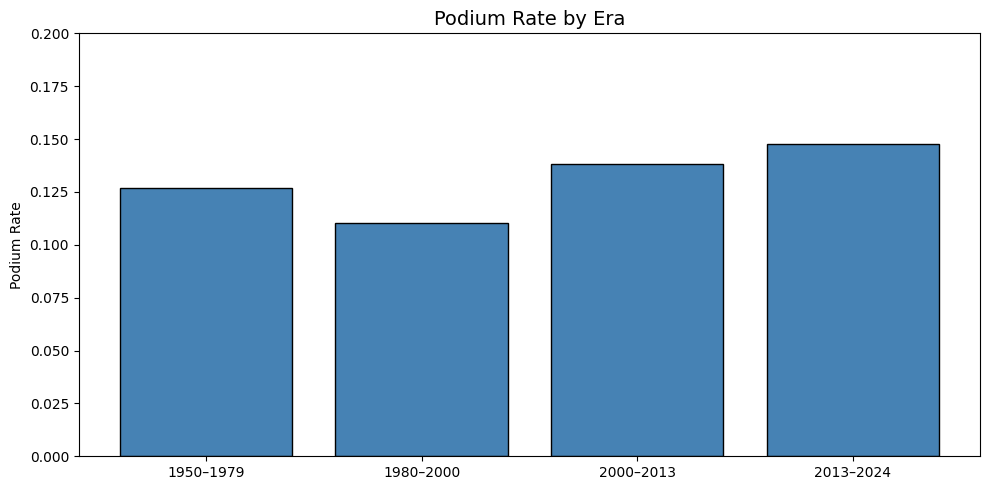

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
era_labels = ['1950–1979', '1980–2000', '2000–2013', '2013–2024']
era_values = [0.1269, 0.1101, 0.1382, 0.1479]
ax.bar(era_labels, era_values, color='steelblue', edgecolor='black')
ax.set_title('Podium Rate by Era', fontsize=14)
ax.set_ylabel('Podium Rate')
ax.set_ylim(0, 0.2)
plt.tight_layout()
plt.show()

**What we learn:** The podium rate is stable across all eras (~11–15%).
The modern era (2013–2024) is the highest because fields are fixed at exactly
20 cars — 3 podiums ÷ 20 cars = 15%. In the 1980s, 30+ cars entered races,
so the rate was lower. This tells us our positive class (podium = 1) represents
roughly 1 in 7–8 rows — a class imbalance we must handle in modeling.

# PLOT 2: Race Outcome Distribution

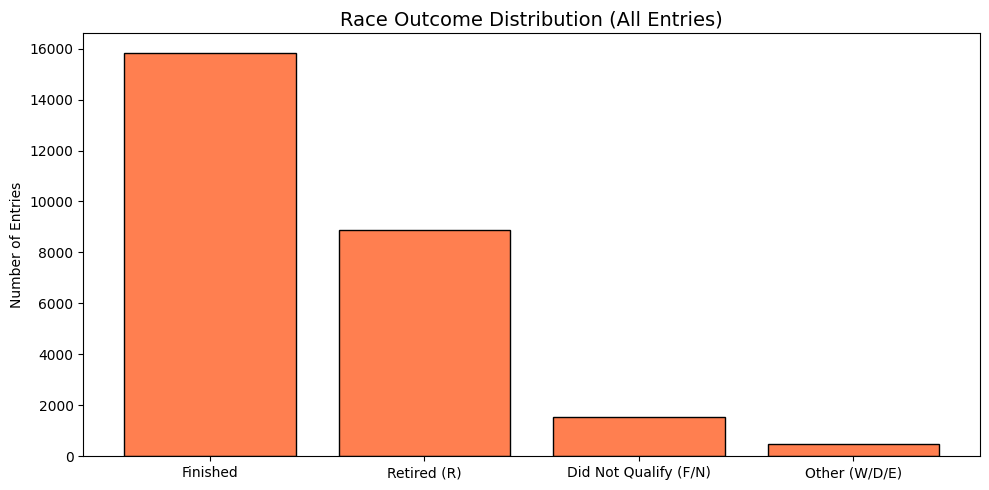

In [20]:
pos_counts = results_df['positionText'].value_counts()
finished = pos_counts[pos_counts.index.str.isnumeric()].sum()
outcome_labels = ['Finished', 'Retired (R)', 'Did Not Qualify (F/N)', 'Other (W/D/E)']
outcome_values = [
    finished,
    pos_counts.get('R', 0),
    pos_counts.get('F', 0) + pos_counts.get('N', 0),
    pos_counts.get('W', 0) + pos_counts.get('D', 0) + pos_counts.get('E', 0)
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(outcome_labels, outcome_values, color='coral', edgecolor='black')
ax.set_title('Race Outcome Distribution (All Entries)', fontsize=14)
ax.set_ylabel('Number of Entries')
plt.tight_layout()
plt.show()

**What we learn:** About one-third of all race entries ended in retirement (R).
This is important because retired drivers cannot podium regardless of their
starting position. The ~2,000 "Did Not Qualify" rows are drivers who never
even started — we will exclude these from our modeling table entirely
(see Decision 2 in cleaning notes). "Other" covers disqualifications,
withdrawals, and exclusions.

# PLOT 3: Podium Rate by Grid Position

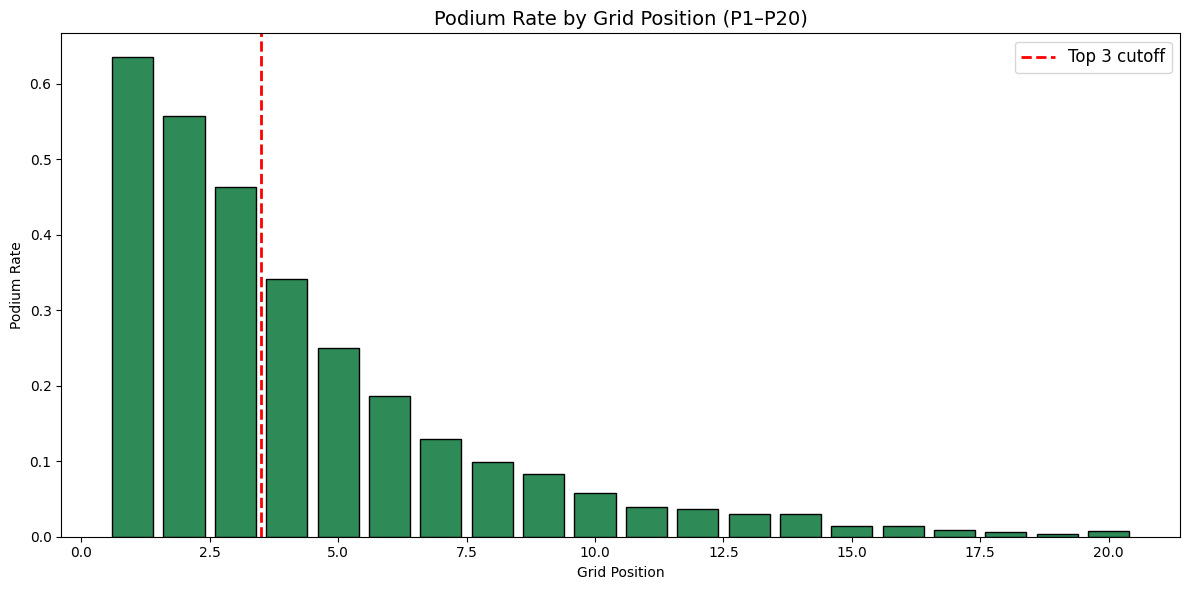

In [21]:
results_with_year = results_df.merge(races_df[['year']], left_on='raceId', right_index=True)
results_with_year['podium'] = (results_with_year['positionOrder'] <= 3)

grid_podium = (results_with_year[results_with_year['grid'].between(1, 20)]
               .groupby('grid')['podium'].mean())

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(grid_podium.index, grid_podium.values, color='seagreen', edgecolor='black')
ax.set_title('Podium Rate by Grid Position (P1–P20)', fontsize=14)
ax.set_xlabel('Grid Position')
ax.set_ylabel('Podium Rate')
ax.axvline(x=3.5, color='red', linestyle='--', linewidth=2, label='Top 3 cutoff')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

**What we learn:** This is the single most important chart in our EDA.
Grid position has a near-perfect monotonic relationship with podium probability:
- Starting P1 → ~65% chance of a podium
- Starting P2 → ~55%
- Starting P3 → ~46%
- Starting P10+ → nearly zero

The drop-off is steep and consistent. This strongly justifies using `grid`
as a feature — in fact it is the most predictive single feature in our model.

Note: `grid` is the **starting** position after penalties are applied.
It differs from qualifying position (`quali_pos`), which we will also include
as a separate feature. Understanding the gap between the two captures
the effect of grid penalties.

## Investigating Duplicate (raceId, driverId) Pairs

We confirmed that 85 duplicate pairs exist. Before deciding how to fix them,
we need to understand *what kind* of duplicates they are.

There are two possible explanations:
1. **Shared drives (1950s–1960s):** A driver took over a teammate's car
   mid-race, resulting in two result rows — one per car driven.
2. **Data entry errors:** The same driver was accidentally recorded twice
   for the same race.

To distinguish between these cases, we examine the `grid` and `positionText`
values for each duplicate pair. If a driver actually started a race, their
`grid` value will be > 0. If both rows show `grid = 0` with `positionText = F`
(failed to qualify), it's likely a data entry error.

In [22]:
# For each duplicate pair, get both rows and check their grid values
dup_index = duplicates.index  # these are (raceId, driverId) tuples

# Get all the duplicate rows
dup_rows = results_df[
    results_df.set_index(['raceId','driverId']).index.isin(dup_index)
].copy()

print(f"Total rows involved in duplicates: {len(dup_rows)}")
print(f"\nGrid value distribution in duplicate rows:")
print(dup_rows['grid'].value_counts().head(10))

print(f"\npositionText distribution in duplicate rows:")
print(dup_rows['positionText'].value_counts())

# How many duplicate PAIRS have at least one row with grid > 0?
dup_rows['has_start'] = dup_rows['grid'] > 0
pairs_with_start = dup_rows.groupby(['raceId','driverId'])['has_start'].any()
print(f"\nDuplicate pairs where driver actually started: {pairs_with_start.sum()}")
print(f"Duplicate pairs where driver never started (all grid=0): {(~pairs_with_start).sum()}")

Total rows involved in duplicates: 176

Grid value distribution in duplicate rows:
grid
1     21
5     15
10    11
6     10
8     10
7     10
11     9
13     8
2      7
12     6
Name: count, dtype: int64

positionText distribution in duplicate rows:
positionText
R     92
4     11
3     10
2      9
11     7
8      6
7      6
6      5
1      5
15     4
F      4
5      4
9      4
W      2
10     2
D      1
12     1
16     1
18     1
19     1
Name: count, dtype: int64

Duplicate pairs where driver actually started: 82
Duplicate pairs where driver never started (all grid=0): 3


In [23]:
# Look at a duplicate where the driver actually started
started_dups = dup_rows[dup_rows['grid'] > 0]
example_race = started_dups.iloc[0]['raceId']
example_driver = started_dups.iloc[0]['driverId']

print(f"Example: raceId={example_race}, driverId={example_driver}")
print(results_df[
    (results_df['raceId'] == example_race) & 
    (results_df['driverId'] == example_driver)
][['raceId','driverId','constructorId','grid','positionOrder','positionText','points','laps']])

# Also check what year these races are from
dup_race_ids = dup_rows['raceId'].unique()
dup_years = races_df.loc[races_df.index.isin(dup_race_ids), 'year']
print(f"\nYears where duplicates occur:")
print(dup_years.value_counts().sort_index())

Example: raceId=717, driverId=373
          raceId  driverId  constructorId  grid  positionOrder positionText  \
resultId                                                                      
17363        717       373            172     1              7            7   
24304        717       373            172     1             12            R   

          points  laps  
resultId                
17363        0.0   102  
24304        0.0    54  

Years where duplicates occur:
year
1950    3
1951    2
1952    3
1953    5
1954    5
1955    4
1956    6
1957    5
1958    3
1960    1
1961    2
1962    1
1964    1
1978    1
Name: count, dtype: int64


**What we found:**
- **82 out of 85** duplicate pairs have `grid > 0` — the driver actually started
  the race. These are genuine shared drives from the 1950s–1964 era.
- **3 pairs** have `grid = 0` with `positionText = F` — these appear to be
  data entry errors (a DNQ driver recorded twice).
- The `positionText` distribution shows many `R` (retired) rows alongside
  numeric positions — consistent with the shared drive pattern where a driver
  retired in one car and then took over another.
- The years confirm it: **all duplicates occur between 1950 and 1978**,
  exactly the era when shared drives were permitted.

**Conclusion:** These are not data errors — they are a real historical quirk
of early F1. We must apply a rule to reduce them to one row per
(raceId, driverId) before modeling (see Decision 1 in cleaning notes).

# PLOT 4: Qualifying Coverage % of Races with Qualifying Data

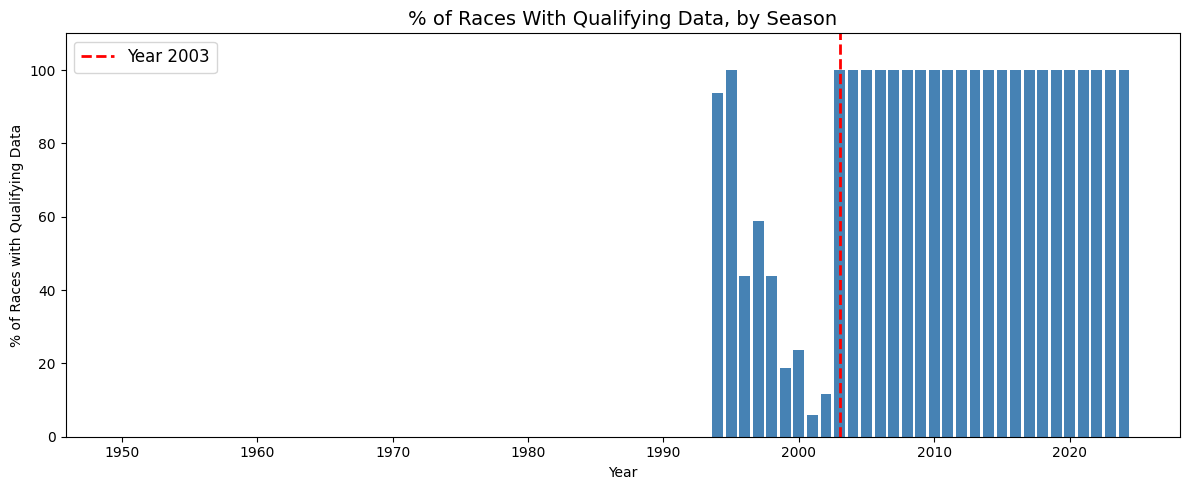

In [24]:
quali_coverage = (qualifying_df
                  .groupby('raceId')['position']
                  .count()
                  .reset_index(name='drivers_with_quali'))

quali_by_year = quali_coverage.merge(
    races_df[['year']], left_on='raceId', right_index=True
)

races_per_year = races_df.groupby('year').size()
races_with_quali = quali_by_year.groupby('year')['raceId'].nunique()
quali_race_coverage = (races_with_quali / races_per_year * 100).fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(quali_race_coverage.index, quali_race_coverage.values,
       color='steelblue', edgecolor='none', width=0.8)
ax.set_title('% of Races With Qualifying Data, by Season', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('% of Races with Qualifying Data')
ax.set_ylim(0, 110)
ax.axvline(x=2003, color='red', linestyle='--', linewidth=2, label='Year 2003')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

**What we learn:** Qualifying data begins appearing in our dataset around **1994**,
not from 2000 as might be assumed. However, coverage before 2003 is unreliable —
dipping as low as 5% in some seasons. From **2003 onward, coverage is 100%** for
every race. Before 1994, there is **no qualifying data at all**.

**Decision (to be implemented):** We will treat qualifying-based features as
reliable only for races from 2003 onward. For races before 2003, we fall back
to `grid` position as a proxy. This also informs our training window choice —
if we include qualifying features, we should consider restricting training to
post-2003 data to avoid large amounts of missingness.

# PLOT 5: Average Drivers with Qualifying Data per Race

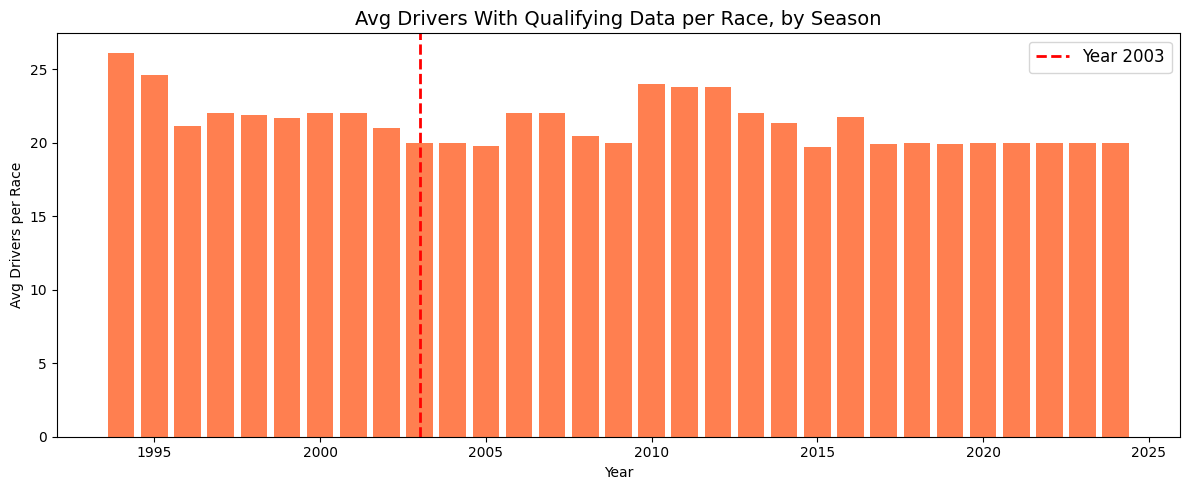

In [25]:
avg_by_year = quali_by_year.groupby('year')['drivers_with_quali'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(avg_by_year.index, avg_by_year.values,
       color='coral', edgecolor='none', width=0.8)
ax.set_title('Avg Drivers With Qualifying Data per Race, by Season', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Avg Drivers per Race')
ax.axvline(x=2003, color='red', linestyle='--', linewidth=2, label='Year 2003')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

**What we learn:** When qualifying data *does* exist for a race, it covers all
drivers who participated in that race (20–26, depending on the era). This tells
us the missingness is **at the race level, not the driver level** — entire races
are either fully covered or fully absent. There is no case of "some drivers have
qualifying times and others don't" within the same race.

This simplifies our imputation strategy: for any race where qualifying data
is missing, we can safely fall back to `grid` position for all drivers in
that race, rather than needing to handle partial missingness within a race.